## NN Module

The torch.nn module in pytorch is a core library that provides a wide array of classes and functions designed to help developers build neural networks efficiently and effectively. It abstracts the complexity of creating and training neural networks by offering pre-build layers, loss functions, activation functions, and other utilities, enabling you to focus on designing and expereminting with the model architectures.


Key components of torch.nn:

1. Modules (Layers):
  - nn.Module : The base class for all neural netword modules. Your custom models and layers should subclass this class.
  - Common Layers: includes layers like nn.Linear (FCC layer), nn.Conv2d (convolutional layer), nn.LSTM (recurrent layer), and many others

2. Activation Functions
 - Functiosn like nn.ReLU, nn.Sigmoid, and NN.Tanh introcude non-linearities to the model, allowing it ot learn complex patterns

3. Loss Functions:
  - Provides loss functiosn such as nn.CrossEntropyLoss, nn.MSELoss, and nn.NLLLoss to quantify the difference between the model's predictiosn and the actual targets.

4. Container modules:
  - nn.Sequential : A sequential container to stack layers in order.

5. Regularization and Dropout:
  - Layers like nn.Dropout and nn.BatchNorm2d help prevent overfitting and improve the model's ability to generalize to new data.

In [7]:
# create the model class

import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):
    super().__init__() # just invoking the parent's class constructor
    self.linear  = nn.Linear(num_features, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    output = self.linear(features)
    output = self.sigmoid(output)

    return output

In [8]:
# creating a fake dataset
features = torch.rand(10,5)

# creating the model
model = Model(features.shape[1])

# forward pass
model(features) # this is a magic method used in the library internally. we can use model(features) instead of calling model.forward(features) function

tensor([[0.4430],
        [0.4972],
        [0.4616],
        [0.5053],
        [0.4375],
        [0.4353],
        [0.5144],
        [0.4380],
        [0.4066],
        [0.5032]], grad_fn=<SigmoidBackward0>)

In [3]:
model.linear.weight

Parameter containing:
tensor([[ 0.0795, -0.0798, -0.1945, -0.0317, -0.0462]], requires_grad=True)

In [4]:
model.linear.bias

Parameter containing:
tensor([0.0004], requires_grad=True)

In [6]:
!pip install torchinfo
from torchinfo import summary

summary(model, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Now a little complex



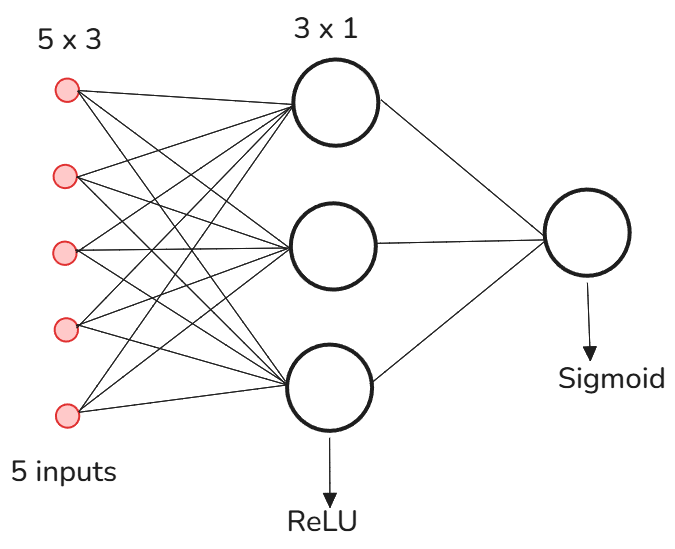

In [9]:
# create the model class

import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):
    super().__init__() # just invoking the parent's class constructor
    self.linear1 = nn.Linear(num_features, 3)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    output = self.linear1(features)
    output = self.relu(output)
    output = self.linear2(features)
    output = self.sigmoid(output)

    return output

In [11]:
# creating a fake dataset
features = torch.rand(10,5)

# creating the model
model = Model(features.shape[1])

In [12]:
model.linear1.weight

Parameter containing:
tensor([[ 0.0419,  0.3198, -0.4048,  0.2283,  0.4312],
        [ 0.1971,  0.1020,  0.3968, -0.1437,  0.3813],
        [-0.2205,  0.3429,  0.1720, -0.0556,  0.0836]], requires_grad=True)

In [13]:
model.linear2.weight

Parameter containing:
tensor([[ 0.0333, -0.0933, -0.1779]], requires_grad=True)

In [14]:
model.linear1.bias

Parameter containing:
tensor([-0.0021, -0.3163, -0.2836], requires_grad=True)

# Now let's use the sequential container

In [18]:
# create the model class

import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):
    super().__init__() # just invoking the parent's class constructor
    self.network = nn.Sequential(
        nn.Linear(num_features,3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid
    )

  def forward(self, features):
    output = self.network(features)

    return output

In [21]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [22]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [23]:
df.shape

(569, 33)

In [24]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)

In [25]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [26]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
X_train

array([[-0.19995636, -1.18458003, -0.21944431, ...,  0.1709298 ,
         0.11771515, -0.63129015],
       [ 3.62613487,  0.57003289,  3.62390818, ...,  2.27194397,
        -0.0813024 , -0.19013255],
       [ 1.53129399,  0.0910773 ,  1.53654218, ...,  2.00031285,
        -0.25729313,  2.43001125],
       ...,
       [ 1.35509242,  1.60270788,  1.47156581, ...,  1.0008304 ,
        -0.97770375,  0.41076377],
       [ 1.66274595,  1.72887179,  1.65837288, ...,  1.46755569,
         0.60127845, -0.43134873],
       [-0.09926975, -0.04443209, -0.16786932, ..., -0.53891284,
        -0.90368896, -0.44689377]])

In [30]:
y_train

,diagnosis
19,B
180,M
252,M
16,M
437,B
...,...
262,M
128,B
83,M
366,M


In [31]:
X_test

array([[-0.54396895, -0.67992438, -0.55529094, ..., -0.46237589,
        -0.4727584 , -0.44367756],
       [ 1.31034281,  0.43919624,  1.24820952, ...,  0.92279273,
        -0.5829582 , -0.99043424],
       [-0.72296737,  0.13780468, -0.71691967, ..., -0.54341501,
         0.49436819,  0.27514667],
       ...,
       [-0.30343982, -0.2827417 , -0.34858486, ..., -0.19374623,
        -1.10270651, -0.81032616],
       [ 1.22364045,  1.32701637,  1.2969418 , ...,  1.01133547,
         0.8858242 ,  0.7211286 ],
       [ 1.37467037,  1.25458893,  1.60557958, ...,  0.88977679,
         0.445025  ,  0.96127271]])

In [32]:
y_test

,diagnosis
74,B
70,M
531,B
64,M
201,M
...,...
411,B
78,M
464,B
30,M


In [33]:
from sklearn.preprocessing import LabelEncoder

# Merge train and test labels, encode them, then split back
all_y = list(y_train) + list(y_test)

encoder = LabelEncoder()
all_encoded = encoder.fit_transform(all_y)

y_train = all_encoded[:len(y_train)]
y_test  = all_encoded[len(y_train):]

In [34]:
y_train

array([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,

In [35]:
y_test

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1])

# now coverting the numpy arrays to pytorch tensors

In [36]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_train)

In [37]:
y_train_tensor

tensor([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [38]:
X_train_tensor

tensor([[-0.2000, -1.1846, -0.2194,  ...,  0.1709,  0.1177, -0.6313],
        [ 3.6261,  0.5700,  3.6239,  ...,  2.2719, -0.0813, -0.1901],
        [ 1.5313,  0.0911,  1.5365,  ...,  2.0003, -0.2573,  2.4300],
        ...,
        [ 1.3551,  1.6027,  1.4716,  ...,  1.0008, -0.9777,  0.4108],
        [ 1.6627,  1.7289,  1.6584,  ...,  1.4676,  0.6013, -0.4313],
        [-0.0993, -0.0444, -0.1679,  ..., -0.5389, -0.9037, -0.4469]],
       dtype=torch.float64)

In [39]:
X_train_tensor.shape

torch.Size([455, 30])

# Defining the model.

In [48]:
import torch.nn as nn
class MySimpleNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.linear = nn.Linear(num_features,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, forward):
    out = self.linear(features)
    out = self.sigmoid(out)
    return out

  def loss_function(self, y_pred, y):
    # clamp predictiosn to avoid log(0)
    epsilon = 1e-7
    y_pred = torch.clamp(y_pred, epsilon, 1-epsilon)

    # calculate loss
    loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1-y_pred)).mean()
    return loss



# Defining the important parameters

In [49]:
lr = 0.1 # learning rate
epochs = 50

# training pipeline

In [52]:
loss_function = nn.BCELoss()

In [ ]:
# creating the model

model = MySimpleNN(X_train_tensor.shape[1])

# loop epochs times
for epoch in range(epochs):

# forward pass
  y_pred = model(X_train_tensor)

# loss calculate
  loss = loss_function(y_pred,y_train_tensor.view(-1,1))

# backward pass
  loss.backward()

# parameters update
  with torch.no_grad():
    model.linear.weight -= lr*model.linear.weight.grad
    model.linear.bias -= lr*model.linear.bias.grad

# zero gradients
  model.linear.weight.grad.zero_()
  model.linear.bias.grad.zero_()

# printing the loss in each epoch
  print(f'Epoch: {epoch + 1 }, Loss: {loss.item()}')

In [ ]:
# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
# updating the parameters
optimizer.step()